In [1]:
import sys
from pathlib import Path

repo_root = Path("/Users/antoinemarion/Documents/Projets/index_engine")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from index_engine.IndexBuilder import IndexBuilder
from index_engine.constraints import UCITS40

fetch data


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [2]:
ix = (
    IndexBuilder("US Momentum", "S&P500")
    .filter_market_cap(max_cap = 4000000000000, min_cap = 100000)
    .filter_price(max_price = 300)
    .rank_by(factor="momentum_6m")
    .select_topN(3)
    .weight(method = "equal_weights")
    .add_constraints(UCITS40())
    .rebalance(frequency = "YS")
    .build()
)

ic = ix.compute("2026-05-28")
ix.constituents()

====MARKET CAP FILTER====
4589945766991.211
3171867261717.6523
4675201561742.389
2947447985464.0
5183308044158.936
1605513206849.9265
1029725168725.4
795091452501.1316
609141462756.1448
555585684253.0432
617971671024.646
947750784396.2662
339765885407.56415
0     0
1     1
2     0
3     1
4     0
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
dtype: int64
====PRICE FILTER====
312.510009765625
426.989990234375
385.88775634765625
634.7017211914062
477.4200134277344
324.95001220703125
0     0
1     0
2     0
3     1
4     1
5     0
6     0
7     1
8     1
9     1
10    0
11    1
12    1
dtype: int64
====SCORING====
nan
nan
nan
0.21088917040010702
nan
nan
nan
0.005348694450168612
0.28432943218471607
0.13973798633071755
nan
0.14947844990807546
0.007296781901023008
====TOP N SELECTOR====
0     0
1     0
2     0
3     1
4     0
5     0
6     0
7     0
8     1
9     0
10    0
11    1
12    0
dtype: int64
====WEIGHTING====
AAPL     0.000000
MSFT     0.000000
GOOG     0.000000
A

Amazon         0.333333
Exxon Mobil    0.333333
Walmart        0.333333
dtype: float64

In [3]:
# ix.universe.get_all_prices().tail()

bt = ix.backtest(
    start="2005-01-06",
    end="2019-01-13"
)

====REBALANCE DATES====
DatetimeIndex(['2005-01-07', '2006-01-03', '2007-01-03', '2008-01-02',
               '2009-01-02', '2010-01-04', '2011-01-03', '2012-01-03',
               '2013-01-02', '2014-01-02', '2015-01-02', '2016-01-04',
               '2017-01-03', '2018-01-02', '2019-01-02'],
              dtype='datetime64[us]', freq=None)
====MARKET CAP FILTER====
15667738519.034424
135989435837.40234
58341776203.59375
22249740015.27954
4199307997.630096
125961273170.4961
61715260823.81152
107230359149.0625
81849825447.46875
94857301622.89308
72639248722.229
0     1
1     1
2     1
3     1
4     1
5     0
6     1
7     1
8     1
9     1
10    0
11    1
12    1
dtype: int64
====PRICE FILTER====
0     1
1     1
2     1
3     1
4     1
5     0
6     1
7     1
8     1
9     1
10    0
11    1
12    1
dtype: int64
====SCORING====
1.3764595510850142
0.0689309892000185
Il n'y a pas 126 jours d'historique avant le 2005-01-07 00:00:00 pour Alphabet Inc..
nan
-0.13720699427241312
0.33434375870

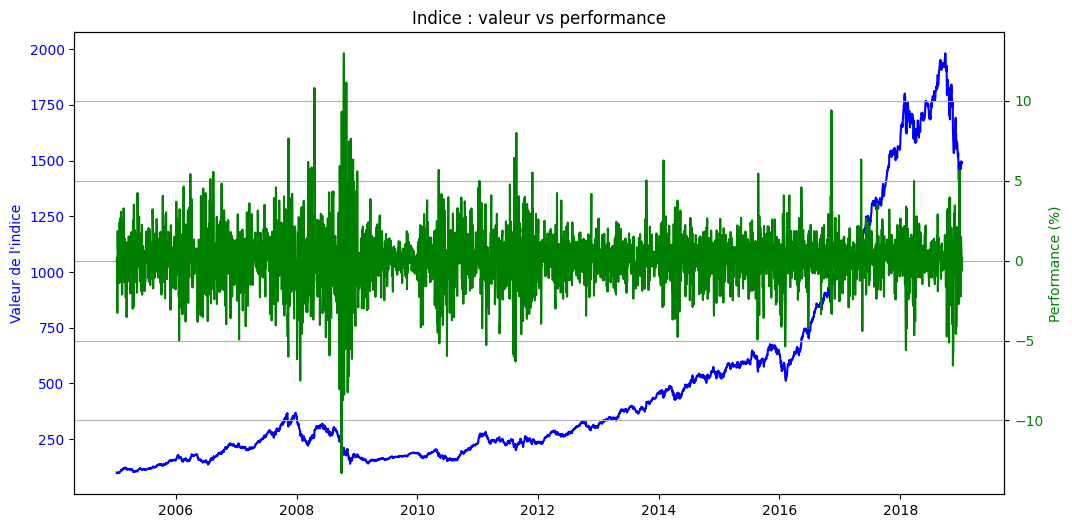

In [4]:
bt.plot_returns()

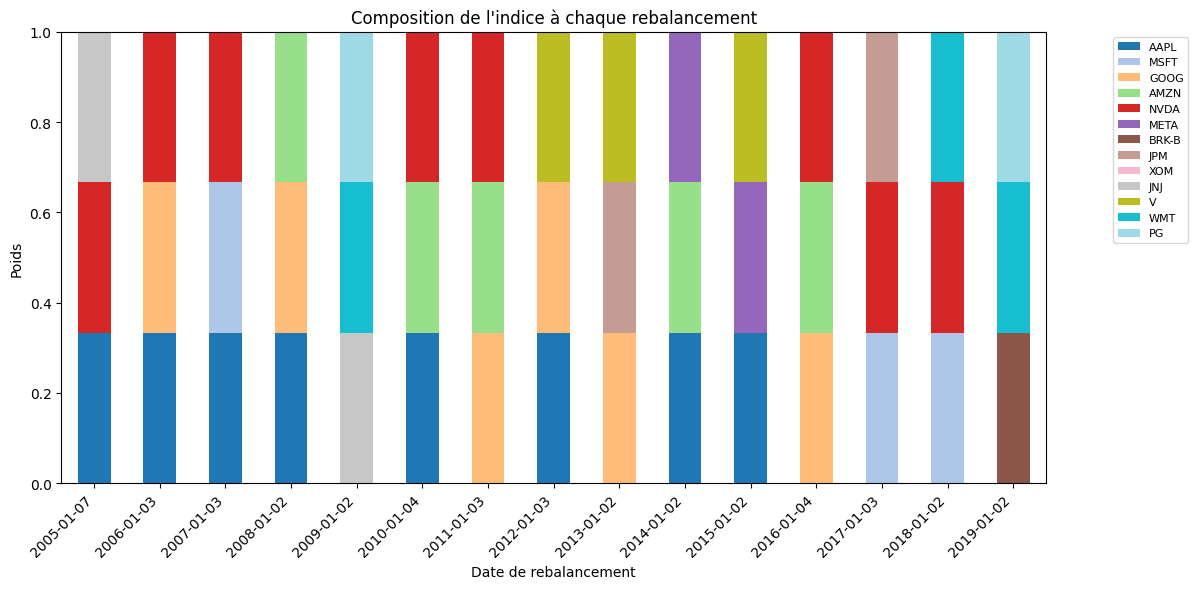

Total return = 1390.21%
Compound Annual Growth Rate = 21.27%
Volatility = 27.07%


In [5]:
bt.plot_weights()
bt.metrics()

In [6]:
index = (
    IndexBuilder("US Momentum Index")

    # univers
    .universe("SP500")

    # filtres d'éligibilité
    .filter_market_cap(min_cap=5e9)
    .filter_liquidity(min_adv=10e6)

    # scoring
    .rank_by(
        factor="momentum_12m",
        ascending=False
    )

    # sélection
    .select_top(50)

    # pondération
    .weight(
        method="inverse_volatility",
        lookback=252
    )

    # contraintes
    .add_constraint(
        UCITS40()
    )

    # rebalancing
    .rebalance(
        frequency="monthly"
    )

    .build()
)

KeyError: "l'univers None n'existe pas"

In [4]:
ix.constituents()

Apple                 0.100000
Microsoft             0.100000
Alphabet Inc.         0.100000
Amazon                0.100000
NVIDIA                0.100000
Meta Platforms        0.098718
Berkshire Hathaway    0.077065
JPMorgan Chase        0.068751
Exxon Mobil           0.061243
Johnson & Johnson     0.059002
Visa                  0.061940
Walmart               0.073281
dtype: float64

In [ ]:
bt = ix.backtest(
    start="2018-01-01",
    end="2025-01-01"
)

In [ ]:
spx = load_benchmark("^GSPC")
bt.compare(spx)